# Phase 6 — Model Selection

This notebook compares the three completed model families using the **same validation set**:

1. Baseline CNN from Phase 3
2. Best augmented CNN from Phase 4
3. Best transfer-learning model from Phase 5

No models are trained in this notebook, and the test set is never loaded.

The primary selection metric is **validation Macro F1**. Ties are resolved using:

1. Higher validation accuracy
2. Lower validation loss
3. Fewer trainable parameters


In [35]:
from __future__ import annotations

import copy
import csv
import importlib
import inspect
import json
import os
import random
import shutil
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Callable, Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.5.1+cu121
Device: cuda
GPU: Quadro RTX 4000


In [36]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    markers = [
        ".git",
        "src",
        "data",
        "results",
        "notebooks",
    ]

    candidates = [start, *start.parents]

    for candidate in candidates:
        marker_count = sum(
            (candidate / marker).exists()
            for marker in markers
        )

        if (candidate / ".git").exists():
            return candidate

        if marker_count >= 3:
            return candidate

    return start


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

# Ensure relative dataset paths are resolved from the repository root,
# not from the notebooks directory.
os.chdir(PROJECT_ROOT)

print(f"Current working directory: {Path.cwd()}")

MODEL_COMPARISON_DIR = (
    RESULTS_DIR / "model_comparison"
)
FINAL_MODEL_DIR = RESULTS_DIR / "final_model"

MODEL_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
FINAL_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {MODEL_COMPARISON_DIR}")


Current working directory: /home/uteam6/computer-vision-equine-grimace-scale
Project root: /home/uteam6/computer-vision-equine-grimace-scale
Output directory: /home/uteam6/computer-vision-equine-grimace-scale/results/model_comparison


In [37]:
CLASS_NAMES = [
    "No Pain",
    "Moderate Pain",
    "Severe Pain",
]

NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE = 64
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = DEVICE.type == "cuda"

IMAGE_SIZE = 224

# Change this only if the validation CSV uses another filename.
VALIDATION_CSV_CANDIDATES = [
    DATA_DIR / "processed" / "validation.csv",
    DATA_DIR / "splits" / "validation.csv",
    DATA_DIR / "validation.csv",
    PROJECT_ROOT / "validation.csv",
]

# Optional normalization metadata produced by earlier phases.
NORMALIZATION_JSON_CANDIDATES = [
    RESULTS_DIR / "data_pipeline" / "normalization_stats.json",
    RESULTS_DIR / "dataset" / "normalization_stats.json",
    DATA_DIR / "processed" / "normalization_stats.json",
]

# Checkpoint candidates are ordered from most canonical to least canonical.
BASELINE_CHECKPOINT_CANDIDATES = [
    RESULTS_DIR / "baseline" / "best_model.pth",
    RESULTS_DIR / "baseline" / "baseline_cnn_best.pth",
    RESULTS_DIR / "baseline" / "best_baseline_model.pth",
    RESULTS_DIR / "baseline_cnn" / "best_model.pth",
    RESULTS_DIR / "baseline_cnn" / "baseline_cnn_best.pth",
]

BASELINE_HISTORY_CANDIDATES = [
    RESULTS_DIR / "baseline" / "history.csv",
    RESULTS_DIR / "baseline" / "baseline_history.csv",
    RESULTS_DIR / "baseline" / "training_history.csv",
    RESULTS_DIR / "baseline_cnn" / "history.csv",
    RESULTS_DIR / "baseline_cnn" / "baseline_history.csv",
]

AUGMENTED_CHECKPOINT_CANDIDATES = [
    RESULTS_DIR / "augmentation_experiments" / "best_augmented_model.pth",
    RESULTS_DIR / "augmentation_experiments" / "checkpoints" / "combined_best.pth",
    RESULTS_DIR / "augmentation_experiments" / "checkpoints" / "random_crop_best.pth",
]

AUGMENTED_HISTORY_CANDIDATES = [
    RESULTS_DIR / "augmentation_experiments" / "best_augmented_history.csv",
    RESULTS_DIR / "augmentation_experiments" / "histories" / "combined_history.csv",
    RESULTS_DIR / "augmentation_experiments" / "histories" / "random_crop_history.csv",
]

TRANSFER_CHECKPOINT_CANDIDATES = [
    RESULTS_DIR / "transfer_learning" / "best_transfer_model.pth",
    RESULTS_DIR / "transfer_learning" / "resnet18_finetuned_best.pth",
    RESULTS_DIR / "transfer_learning" / "resnet18_frozen_best.pth",
]

TRANSFER_HISTORY_CANDIDATES = [
    RESULTS_DIR / "transfer_learning" / "best_transfer_history.csv",
    RESULTS_DIR / "transfer_learning" / "resnet18_finetuned_history.csv",
    RESULTS_DIR / "transfer_learning" / "resnet18_frozen_history.csv",
]


def first_existing_path(
    candidates: Iterable[Path],
    description: str,
) -> Path:
    for path in candidates:
        if path.exists():
            print(f"{description}: {path}")
            return path

    formatted = "\n".join(
        f"  - {path}"
        for path in candidates
    )

    raise FileNotFoundError(
        f"Could not find {description}. Checked:\n{formatted}"
    )


VALIDATION_CSV = first_existing_path(
    VALIDATION_CSV_CANDIDATES,
    "Validation CSV",
)

BASELINE_CHECKPOINT = first_existing_path(
    BASELINE_CHECKPOINT_CANDIDATES,
    "Baseline checkpoint",
)

BASELINE_HISTORY = first_existing_path(
    BASELINE_HISTORY_CANDIDATES,
    "Baseline history",
)

AUGMENTED_CHECKPOINT = first_existing_path(
    AUGMENTED_CHECKPOINT_CANDIDATES,
    "Augmented CNN checkpoint",
)

AUGMENTED_HISTORY = first_existing_path(
    AUGMENTED_HISTORY_CANDIDATES,
    "Augmented CNN history",
)

TRANSFER_CHECKPOINT = first_existing_path(
    TRANSFER_CHECKPOINT_CANDIDATES,
    "Transfer-learning checkpoint",
)

TRANSFER_HISTORY = first_existing_path(
    TRANSFER_HISTORY_CANDIDATES,
    "Transfer-learning history",
)


Validation CSV: /home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv
Baseline checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/best_model.pth
Baseline history: /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/training_history.csv
Augmented CNN checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/best_augmented_model.pth
Augmented CNN history: /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/best_augmented_history.csv
Transfer-learning checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/best_transfer_model.pth
Transfer-learning history: /home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/best_transfer_history.csv


In [38]:
def safe_torch_load(
    path: Path,
    map_location: torch.device | str = "cpu",
) -> Any:
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location,
        )


def describe_checkpoint(path: Path) -> None:
    checkpoint = safe_torch_load(path)

    print(f"\n{path.name}")
    print("-" * len(path.name))

    if isinstance(checkpoint, dict):
        keys = list(checkpoint.keys())
        print(f"Top-level keys: {keys[:20]}")

        tensor_keys = [
            key
            for key, value in checkpoint.items()
            if torch.is_tensor(value)
        ]

        if tensor_keys:
            print(
                "Appears to be a raw state dictionary "
                f"with {len(tensor_keys)} tensor entries."
            )
    else:
        print(f"Stored object type: {type(checkpoint)}")


for checkpoint_path in [
    BASELINE_CHECKPOINT,
    AUGMENTED_CHECKPOINT,
    TRANSFER_CHECKPOINT,
]:
    describe_checkpoint(checkpoint_path)



best_model.pth
--------------
Top-level keys: ['model_state_dict', 'validation_loss', 'optimizer_state_dict', 'epoch', 'history', 'num_classes']

best_augmented_model.pth
------------------------
Top-level keys: ['model_state_dict', 'validation_loss', 'optimizer_state_dict', 'epoch', 'history', 'num_classes']

best_transfer_model.pth
-----------------------
Top-level keys: ['model_state_dict', 'validation_loss', 'optimizer_state_dict', 'epoch', 'history', 'num_classes', 'architecture', 'training_mode', 'dropout_rate', 'pretrained_weights', 'augmentation', 'normalization', 'image_size', 'resize_size', 'class_names', 'class_weights', 'selection_metric', 'selection_metric_value', 'source_checkpoint', 'source_history']


In [39]:
def import_first_available(
    module_names: list[str],
    attribute_names: list[str],
) -> Any:
    errors: list[str] = []

    for module_name in module_names:
        try:
            module = importlib.import_module(module_name)
        except Exception as error:
            errors.append(
                f"{module_name}: {type(error).__name__}: {error}"
            )
            continue

        for attribute_name in attribute_names:
            if hasattr(module, attribute_name):
                return getattr(module, attribute_name)

    details = "\n".join(errors[-10:])

    raise ImportError(
        "Could not import any requested attribute.\n"
        f"Modules checked: {module_names}\n"
        f"Attributes checked: {attribute_names}\n"
        f"Recent import errors:\n{details}"
    )


HorseGrimaceDataset = import_first_available(
    module_names=[
        "src.datasets.horse_dataset",
        "datasets.horse_dataset",
        "horse_dataset",
    ],
    attribute_names=[
        "HorseGrimaceDataset",
    ],
)

print(
    "Dataset class:",
    f"{HorseGrimaceDataset.__module__}."
    f"{HorseGrimaceDataset.__name__}",
)


Dataset class: src.datasets.horse_dataset.HorseGrimaceDataset


In [40]:
def load_normalization_stats() -> tuple[list[float], list[float]]:
    default_mean = [0.485, 0.456, 0.406]
    default_std = [0.229, 0.224, 0.225]

    for path in NORMALIZATION_JSON_CANDIDATES:
        if not path.exists():
            continue

        try:
            with path.open("r", encoding="utf-8") as file:
                data = json.load(file)

            mean = (
                data.get("mean")
                or data.get("channel_mean")
                or data.get("train_mean")
            )
            std = (
                data.get("std")
                or data.get("channel_std")
                or data.get("train_std")
            )

            if (
                isinstance(mean, list)
                and isinstance(std, list)
                and len(mean) == 3
                and len(std) == 3
            ):
                print(
                    "Using normalization statistics from:",
                    path,
                )
                return mean, std
        except Exception as error:
            print(
                f"Could not read {path}: {error}"
            )

    print(
        "Using ImageNet normalization. "
        "This is required for ResNet18 and is also used "
        "for a fair shared validation pipeline."
    )
    return default_mean, default_std


NORMALIZATION_MEAN, NORMALIZATION_STD = (
    load_normalization_stats()
)

VALIDATION_TRANSFORM = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=NORMALIZATION_MEAN,
            std=NORMALIZATION_STD,
        ),
    ]
)

print("Mean:", NORMALIZATION_MEAN)
print("Std:", NORMALIZATION_STD)


Using ImageNet normalization. This is required for ResNet18 and is also used for a fair shared validation pipeline.
Mean: [0.485, 0.456, 0.406]
Std: [0.229, 0.224, 0.225]


In [41]:
def instantiate_dataset(
    dataset_class: type,
    csv_path: Path,
    transform: Callable,
):
    signature = inspect.signature(
        dataset_class.__init__
    )
    parameter_names = set(signature.parameters)

    attempts: list[dict[str, Any]] = []

    csv_parameter_options = [
        "csv_path",
        "annotations_file",
        "annotation_file",
        "metadata_path",
        "dataframe_path",
    ]

    transform_parameter_options = [
        "transform",
        "transforms",
        "image_transform",
    ]

    csv_parameter = next(
        (
            name
            for name in csv_parameter_options
            if name in parameter_names
        ),
        None,
    )
    transform_parameter = next(
        (
            name
            for name in transform_parameter_options
            if name in parameter_names
        ),
        None,
    )

    if csv_parameter is not None:
        kwargs: dict[str, Any] = {
            csv_parameter: csv_path,
        }

        if transform_parameter is not None:
            kwargs[transform_parameter] = transform

        if "root_dir" in parameter_names:
            kwargs["root_dir"] = PROJECT_ROOT

        if "image_dir" in parameter_names:
            kwargs["image_dir"] = (
                DATA_DIR / "processed" / "images"
            )

        attempts.append(kwargs)

    attempts.extend(
        [
            {
                "csv_path": csv_path,
                "transform": transform,
            },
            {
                "annotations_file": csv_path,
                "transform": transform,
            },
        ]
    )

    errors: list[str] = []

    for kwargs in attempts:
        try:
            return dataset_class(**kwargs)
        except Exception as error:
            errors.append(
                f"{kwargs}: {type(error).__name__}: {error}"
            )

    try:
        return dataset_class(
            csv_path,
            transform=transform,
        )
    except Exception as error:
        errors.append(
            "Positional CSV attempt: "
            f"{type(error).__name__}: {error}"
        )

    raise RuntimeError(
        "Could not instantiate HorseGrimaceDataset.\n"
        + "\n".join(errors)
    )


validation_dataset = instantiate_dataset(
    HorseGrimaceDataset,
    VALIDATION_CSV,
    VALIDATION_TRANSFORM,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

print(
    f"Validation samples: {len(validation_dataset)}"
)
print(
    f"Validation batches: {len(validation_loader)}"
)

sample_batch = next(iter(validation_loader))

if isinstance(sample_batch, dict):
    print("Batch dictionary keys:", sample_batch.keys())
else:
    print(
        "Batch container type:",
        type(sample_batch).__name__,
    )


Validation samples: 315
Validation batches: 5


Batch dictionary keys: dict_keys(['image', 'pain_score', 'horse_id', 'face_region', 'image_path'])


In [42]:
def strip_prefix(
    state_dict: dict[str, torch.Tensor],
    prefix: str,
) -> dict[str, torch.Tensor]:
    if not state_dict:
        return state_dict

    if all(key.startswith(prefix) for key in state_dict):
        return {
            key[len(prefix):]: value
            for key, value in state_dict.items()
        }

    return state_dict


def extract_state_dict(
    checkpoint: Any,
) -> dict[str, torch.Tensor]:
    if isinstance(checkpoint, nn.Module):
        return checkpoint.state_dict()

    if not isinstance(checkpoint, dict):
        raise TypeError(
            "Checkpoint must be a state dictionary, "
            "a checkpoint dictionary, or an nn.Module."
        )

    candidate_keys = [
        "model_state_dict",
        "state_dict",
        "model",
        "network_state_dict",
        "best_model_state_dict",
    ]

    for key in candidate_keys:
        value = checkpoint.get(key)

        if isinstance(value, nn.Module):
            return value.state_dict()

        if isinstance(value, dict):
            if value and all(
                torch.is_tensor(item)
                for item in value.values()
            ):
                state_dict = value
                break
    else:
        if checkpoint and all(
            torch.is_tensor(value)
            for value in checkpoint.values()
        ):
            state_dict = checkpoint
        else:
            raise KeyError(
                "No model state dictionary was found. "
                f"Checkpoint keys: {list(checkpoint.keys())}"
            )

    for prefix in [
        "model.",
        "module.",
        "_orig_mod.",
        "network.",
    ]:
        state_dict = strip_prefix(
            state_dict,
            prefix,
        )

    return state_dict


def extract_checkpoint_metadata(
    checkpoint: Any,
) -> dict[str, Any]:
    if not isinstance(checkpoint, dict):
        return {}

    metadata = {}

    for key in [
        "epoch",
        "best_epoch",
        "validation_loss",
        "val_loss",
        "validation_accuracy",
        "val_accuracy",
        "validation_macro_f1",
        "val_macro_f1",
        "class_names",
        "num_classes",
        "model_name",
        "architecture",
        "training_time",
        "training_time_seconds",
    ]:
        if key in checkpoint:
            value = checkpoint[key]

            if not torch.is_tensor(value):
                metadata[key] = value

    return metadata


def build_resnet18(
    num_classes: int = NUM_CLASSES,
) -> nn.Module:
    model = models.resnet18(weights=None)

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(
            in_features,
            num_classes,
        ),
    )

    return model


def search_project_model_constructor(
    preferred_names: list[str],
) -> Callable[..., nn.Module]:
    module_candidates = [
        "src.models.baseline_cnn",
        "src.models.cnn",
        "src.models.model",
        "src.models.models",
        "src.models",
        "models.baseline_cnn",
        "models.cnn",
        "models.model",
        "models.models",
        "baseline_cnn",
        "cnn",
        "model",
    ]

    imported_modules = []

    for module_name in module_candidates:
        try:
            imported_modules.append(
                importlib.import_module(module_name)
            )
        except Exception:
            continue

    for module in imported_modules:
        for name in preferred_names:
            candidate = getattr(
                module,
                name,
                None,
            )

            if (
                inspect.isclass(candidate)
                and issubclass(candidate, nn.Module)
            ):
                return candidate

            if callable(candidate):
                return candidate

    available = {}

    for module in imported_modules:
        names = [
            name
            for name, value in vars(module).items()
            if (
                inspect.isclass(value)
                and issubclass(value, nn.Module)
            )
        ]

        if names:
            available[module.__name__] = names

    raise ImportError(
        "Could not find the CNN constructor used in "
        "Phases 3 and 4.\n"
        f"Preferred names: {preferred_names}\n"
        f"Detected nn.Module classes: {available}\n\n"
        "Add the exact class name to preferred_names or "
        "import your model class directly in this cell."
    )


def instantiate_model_constructor(
    constructor: Callable[..., nn.Module],
    num_classes: int = NUM_CLASSES,
) -> nn.Module:
    attempts = [
        {"num_classes": num_classes},
        {"n_classes": num_classes},
        {"output_classes": num_classes},
        {"classes": num_classes},
        {},
    ]

    errors = []

    for kwargs in attempts:
        try:
            model = constructor(**kwargs)

            if isinstance(model, nn.Module):
                return model
        except Exception as error:
            errors.append(
                f"{kwargs}: {type(error).__name__}: {error}"
            )

    raise RuntimeError(
        f"Could not instantiate {constructor}.\n"
        + "\n".join(errors)
    )


CNN_CONSTRUCTOR = search_project_model_constructor(
    preferred_names=[
        "BaselineCNN",
        "BaselineCNNModel",
        "HorseBaselineCNN",
        "HorseGrimaceCNN",
        "CustomCNN",
        "SimpleCNN",
        "CNNModel",
        "CNN",
    ]
)

print(
    "CNN constructor:",
    f"{CNN_CONSTRUCTOR.__module__}."
    f"{CNN_CONSTRUCTOR.__name__}",
)


CNN constructor: src.models.baseline_cnn.BaselineCNN


In [43]:
@dataclass
class ModelSpecification:
    display_name: str
    family: str
    checkpoint_path: Path
    history_path: Path
    constructor: Callable[[], nn.Module]


MODEL_SPECIFICATIONS = [
    ModelSpecification(
        display_name="Baseline CNN",
        family="baseline_cnn",
        checkpoint_path=BASELINE_CHECKPOINT,
        history_path=BASELINE_HISTORY,
        constructor=lambda: instantiate_model_constructor(
            CNN_CONSTRUCTOR
        ),
    ),
    ModelSpecification(
        display_name="Augmented CNN",
        family="augmented_cnn",
        checkpoint_path=AUGMENTED_CHECKPOINT,
        history_path=AUGMENTED_HISTORY,
        constructor=lambda: instantiate_model_constructor(
            CNN_CONSTRUCTOR
        ),
    ),
    ModelSpecification(
        display_name="Transfer Learning",
        family="resnet18",
        checkpoint_path=TRANSFER_CHECKPOINT,
        history_path=TRANSFER_HISTORY,
        constructor=build_resnet18,
    ),
]


def load_model_from_specification(
    specification: ModelSpecification,
) -> tuple[nn.Module, dict[str, Any]]:
    checkpoint = safe_torch_load(
        specification.checkpoint_path,
        map_location="cpu",
    )
    metadata = extract_checkpoint_metadata(
        checkpoint
    )

    if isinstance(checkpoint, nn.Module):
        model = checkpoint
    else:
        model = specification.constructor()
        state_dict = extract_state_dict(checkpoint)

        try:
            model.load_state_dict(
                state_dict,
                strict=True,
            )
        except RuntimeError as error:
            model_keys = set(model.state_dict())
            checkpoint_keys = set(state_dict)

            missing = sorted(
                model_keys - checkpoint_keys
            )
            unexpected = sorted(
                checkpoint_keys - model_keys
            )

            raise RuntimeError(
                f"Checkpoint incompatibility for "
                f"{specification.display_name}.\n"
                f"Checkpoint: {specification.checkpoint_path}\n"
                f"Missing keys, first 15: {missing[:15]}\n"
                f"Unexpected keys, first 15: "
                f"{unexpected[:15]}\n\n"
                "This normally means the model constructor "
                "does not exactly match the architecture used "
                "during training."
            ) from error

    model = model.to(DEVICE)
    model.eval()

    return model, metadata


loaded_models: dict[str, nn.Module] = {}
checkpoint_metadata: dict[str, dict[str, Any]] = {}

for specification in MODEL_SPECIFICATIONS:
    model, metadata = load_model_from_specification(
        specification
    )

    loaded_models[specification.display_name] = model
    checkpoint_metadata[
        specification.display_name
    ] = metadata

    print(
        f"Loaded {specification.display_name} "
        f"from {specification.checkpoint_path}"
    )


Loaded Baseline CNN from /home/uteam6/computer-vision-equine-grimace-scale/results/baseline/best_model.pth
Loaded Augmented CNN from /home/uteam6/computer-vision-equine-grimace-scale/results/augmentation_experiments/best_augmented_model.pth
Loaded Transfer Learning from /home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/best_transfer_model.pth


In [44]:
def unpack_batch(
    batch: Any,
) -> tuple[torch.Tensor, torch.Tensor]:
    if isinstance(batch, (tuple, list)):
        if len(batch) < 2:
            raise ValueError(
                "Tuple/list batch must contain images and labels."
            )

        return batch[0], batch[1]

    if isinstance(batch, dict):
        image_keys = [
            "image",
            "images",
            "pixel_values",
            "input",
            "inputs",
        ]
        label_keys = [
            "label",
            "labels",
            "target",
            "targets",
            "pain_score",
            "class_id",
        ]

        images = next(
            (
                batch[key]
                for key in image_keys
                if key in batch
            ),
            None,
        )
        labels = next(
            (
                batch[key]
                for key in label_keys
                if key in batch
            ),
            None,
        )

        if images is None or labels is None:
            raise KeyError(
                "Could not identify image and label keys. "
                f"Available keys: {list(batch.keys())}"
            )

        return images, labels

    raise TypeError(
        f"Unsupported batch type: {type(batch)}"
    )


def count_parameters(
    model: nn.Module,
) -> tuple[int, int]:
    total = sum(
        parameter.numel()
        for parameter in model.parameters()
    )
    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return total, trainable


@torch.inference_mode()
def evaluate_model(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
) -> dict[str, Any]:
    model.eval()

    running_loss = 0.0
    sample_count = 0

    all_targets: list[int] = []
    all_predictions: list[int] = []

    start_time = time.perf_counter()

    for batch in data_loader:
        images, targets = unpack_batch(batch)

        images = images.to(
            DEVICE,
            non_blocking=True,
        )
        targets = targets.to(
            DEVICE,
            non_blocking=True,
        ).long()

        logits = model(images)
        loss = criterion(logits, targets)

        predictions = logits.argmax(dim=1)
        batch_size = targets.size(0)

        running_loss += loss.item() * batch_size
        sample_count += batch_size

        all_targets.extend(
            targets.detach().cpu().tolist()
        )
        all_predictions.extend(
            predictions.detach().cpu().tolist()
        )

    elapsed_seconds = (
        time.perf_counter() - start_time
    )

    if sample_count == 0:
        raise RuntimeError(
            "The validation loader produced no samples."
        )

    targets_array = np.asarray(all_targets)
    predictions_array = np.asarray(
        all_predictions
    )

    accuracy = accuracy_score(
        targets_array,
        predictions_array,
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            targets_array,
            predictions_array,
            average="macro",
            labels=list(range(NUM_CLASSES)),
            zero_division=0,
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            targets_array,
            predictions_array,
            average="weighted",
            labels=list(range(NUM_CLASSES)),
            zero_division=0,
        )
    )

    total_parameters, trainable_parameters = (
        count_parameters(model)
    )

    return {
        "validation_loss": (
            running_loss / sample_count
        ),
        "validation_accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "parameter_count": total_parameters,
        "trainable_parameter_count": (
            trainable_parameters
        ),
        "validation_samples": sample_count,
        "evaluation_time_seconds": elapsed_seconds,
        "targets": targets_array,
        "predictions": predictions_array,
    }


In [45]:
criterion = nn.CrossEntropyLoss()

evaluation_rows: list[dict[str, Any]] = []
prediction_cache: dict[str, dict[str, np.ndarray]] = {}

for specification in MODEL_SPECIFICATIONS:
    model = loaded_models[
        specification.display_name
    ]

    print(
        f"Evaluating {specification.display_name}..."
    )

    metrics = evaluate_model(
        model=model,
        data_loader=validation_loader,
        criterion=criterion,
    )

    prediction_cache[
        specification.display_name
    ] = {
        "targets": metrics.pop("targets"),
        "predictions": metrics.pop(
            "predictions"
        ),
    }

    row = {
        "model": specification.display_name,
        "family": specification.family,
        "checkpoint_path": str(
            specification.checkpoint_path
        ),
        "history_path": str(
            specification.history_path
        ),
        **metrics,
    }

    evaluation_rows.append(row)

evaluation_df = pd.DataFrame(evaluation_rows)

metric_columns = [
    "model",
    "validation_loss",
    "validation_accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_f1",
    "parameter_count",
    "trainable_parameter_count",
    "evaluation_time_seconds",
]

display(
    evaluation_df[metric_columns].style.format(
        {
            "validation_loss": "{:.4f}",
            "validation_accuracy": "{:.4f}",
            "macro_precision": "{:.4f}",
            "macro_recall": "{:.4f}",
            "macro_f1": "{:.4f}",
            "weighted_f1": "{:.4f}",
            "parameter_count": "{:,.0f}",
            "trainable_parameter_count": "{:,.0f}",
            "evaluation_time_seconds": "{:.2f}",
        }
    )
)


Evaluating Baseline CNN...
Evaluating Augmented CNN...
Evaluating Transfer Learning...


,model,validation_loss,validation_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,parameter_count,trainable_parameter_count,evaluation_time_seconds
0,Baseline CNN,0.7412,0.7111,0.5719,0.5828,0.5675,0.7148,"389,667","389,667",0.40
1,Augmented CNN,0.7404,0.7048,0.5928,0.6042,0.5695,0.7120,"389,667","389,667",0.27
2,Transfer Learning,0.6040,0.7524,0.6483,0.6615,0.6497,0.7567,"11,178,051","11,178,051",0.29


In [46]:
COLUMN_ALIASES = {
    "epoch": [
        "epoch",
        "Epoch",
        "current_epoch",
    ],
    "training_loss": [
        "training_loss",
        "train_loss",
        "loss",
        "Train Loss",
    ],
    "validation_loss": [
        "validation_loss",
        "val_loss",
        "valid_loss",
        "Validation Loss",
    ],
    "validation_accuracy": [
        "validation_accuracy",
        "val_accuracy",
        "valid_accuracy",
        "val_acc",
        "Validation Accuracy",
    ],
    "validation_macro_f1": [
        "validation_macro_f1",
        "val_macro_f1",
        "macro_f1",
        "val_f1_macro",
        "Validation Macro F1",
    ],
    "training_time_seconds": [
        "training_time_seconds",
        "elapsed_seconds",
        "epoch_time_seconds",
        "training_seconds",
        "time_seconds",
    ],
}


def find_column(
    dataframe: pd.DataFrame,
    aliases: list[str],
) -> str | None:
    exact_lookup = {
        str(column).strip(): column
        for column in dataframe.columns
    }
    lower_lookup = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for alias in aliases:
        if alias in exact_lookup:
            return exact_lookup[alias]

        if alias.lower() in lower_lookup:
            return lower_lookup[alias.lower()]

    return None


def standardize_history(
    history_path: Path,
    model_name: str,
) -> pd.DataFrame:
    dataframe = pd.read_csv(history_path)
    standardized = pd.DataFrame()

    for standard_name, aliases in (
        COLUMN_ALIASES.items()
    ):
        source_column = find_column(
            dataframe,
            aliases,
        )

        if source_column is not None:
            standardized[standard_name] = (
                pd.to_numeric(
                    dataframe[source_column],
                    errors="coerce",
                )
            )

    if "epoch" not in standardized:
        standardized["epoch"] = np.arange(
            1,
            len(dataframe) + 1,
        )

    standardized["model"] = model_name

    ordered_columns = [
        "model",
        "epoch",
        "training_loss",
        "validation_loss",
        "validation_accuracy",
        "validation_macro_f1",
        "training_time_seconds",
    ]

    existing_columns = [
        column
        for column in ordered_columns
        if column in standardized
    ]

    return standardized[existing_columns]


history_frames = []

for specification in MODEL_SPECIFICATIONS:
    history_frame = standardize_history(
        specification.history_path,
        specification.display_name,
    )
    history_frames.append(history_frame)

    print(
        f"{specification.display_name}: "
        f"{len(history_frame)} history rows; "
        f"columns={history_frame.columns.tolist()}"
    )

combined_history_df = pd.concat(
    history_frames,
    ignore_index=True,
)

display(combined_history_df.head())


Baseline CNN: 29 history rows; columns=['model', 'epoch', 'training_loss', 'validation_loss', 'validation_accuracy', 'validation_macro_f1']
Augmented CNN: 41 history rows; columns=['model', 'epoch', 'training_loss', 'validation_loss', 'validation_accuracy', 'validation_macro_f1']
Transfer Learning: 18 history rows; columns=['model', 'epoch', 'training_loss', 'validation_loss', 'validation_accuracy', 'validation_macro_f1']


,model,epoch,training_loss,validation_loss,validation_accuracy,validation_macro_f1
0,Baseline CNN,1,1.025686,0.820152,0.647619,0.457015
1,Baseline CNN,2,0.976113,0.818530,0.653968,0.460097
2,Baseline CNN,3,0.983242,0.814988,0.676190,0.471960
3,Baseline CNN,4,0.957424,0.832646,0.641270,0.466922
4,Baseline CNN,5,0.963270,0.847947,0.641270,0.470363


In [47]:
def history_summary(
    history: pd.DataFrame,
) -> dict[str, Any]:
    result: dict[str, Any] = {}

    if (
        "validation_macro_f1" in history
        and history[
            "validation_macro_f1"
        ].notna().any()
    ):
        best_index = history[
            "validation_macro_f1"
        ].idxmax()

        result["best_epoch"] = int(
            history.loc[best_index, "epoch"]
        )
        result[
            "history_best_validation_macro_f1"
        ] = float(
            history.loc[
                best_index,
                "validation_macro_f1",
            ]
        )
    elif (
        "validation_loss" in history
        and history[
            "validation_loss"
        ].notna().any()
    ):
        best_index = history[
            "validation_loss"
        ].idxmin()

        result["best_epoch"] = int(
            history.loc[best_index, "epoch"]
        )
    else:
        result["best_epoch"] = np.nan

    if (
        "training_time_seconds" in history
        and history[
            "training_time_seconds"
        ].notna().any()
    ):
        values = history[
            "training_time_seconds"
        ].dropna()

        # Most histories store per-epoch durations.
        # If the sequence is monotonically cumulative,
        # use the last value instead.
        if len(values) > 1 and values.is_monotonic_increasing:
            result["training_time_seconds"] = (
                float(values.iloc[-1])
            )
        else:
            result["training_time_seconds"] = (
                float(values.sum())
            )
    else:
        result["training_time_seconds"] = np.nan

    return result


history_summary_rows = []

for specification, history_frame in zip(
    MODEL_SPECIFICATIONS,
    history_frames,
):
    summary = history_summary(history_frame)

    metadata = checkpoint_metadata.get(
        specification.display_name,
        {},
    )

    if pd.isna(summary["best_epoch"]):
        for key in ["best_epoch", "epoch"]:
            if key in metadata:
                summary["best_epoch"] = (
                    int(metadata[key])
                )
                break

    if pd.isna(
        summary["training_time_seconds"]
    ):
        for key in [
            "training_time_seconds",
            "training_time",
        ]:
            if key in metadata:
                try:
                    summary[
                        "training_time_seconds"
                    ] = float(metadata[key])
                except (TypeError, ValueError):
                    pass
                break

    history_summary_rows.append(
        {
            "model": specification.display_name,
            **summary,
        }
    )

history_summary_df = pd.DataFrame(
    history_summary_rows
)

experiment_summary_df = evaluation_df.merge(
    history_summary_df,
    on="model",
    how="left",
)

display(
    experiment_summary_df[
        [
            "model",
            "best_epoch",
            "training_time_seconds",
            "parameter_count",
            "trainable_parameter_count",
        ]
    ]
)


,model,best_epoch,training_time_seconds,parameter_count,trainable_parameter_count
0,Baseline CNN,29,NaN,389667,389667
1,Augmented CNN,35,NaN,389667,389667
2,Transfer Learning,10,NaN,11178051,11178051


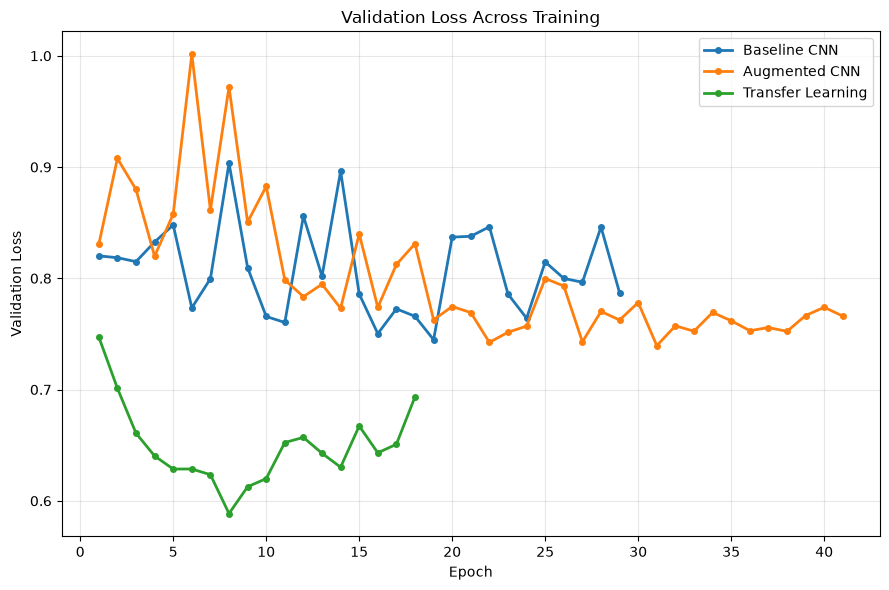

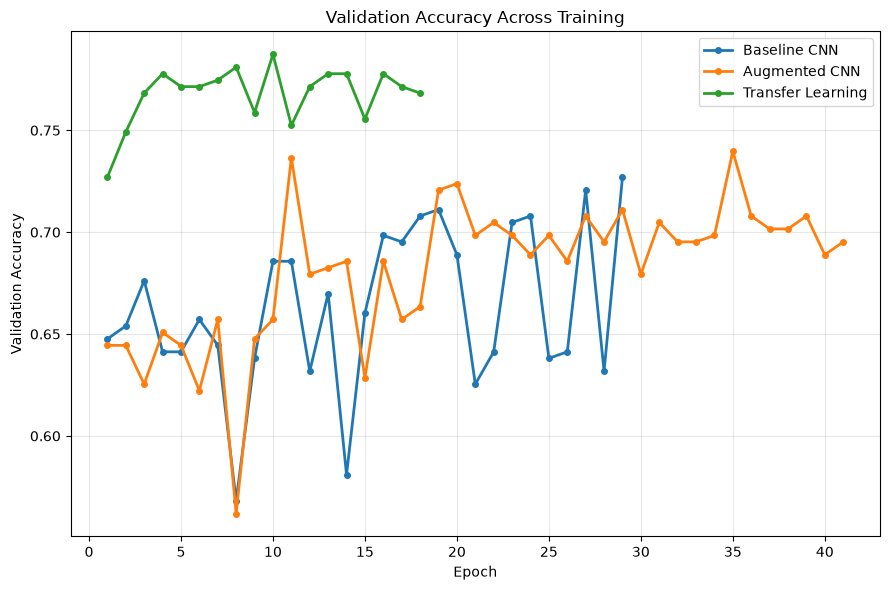

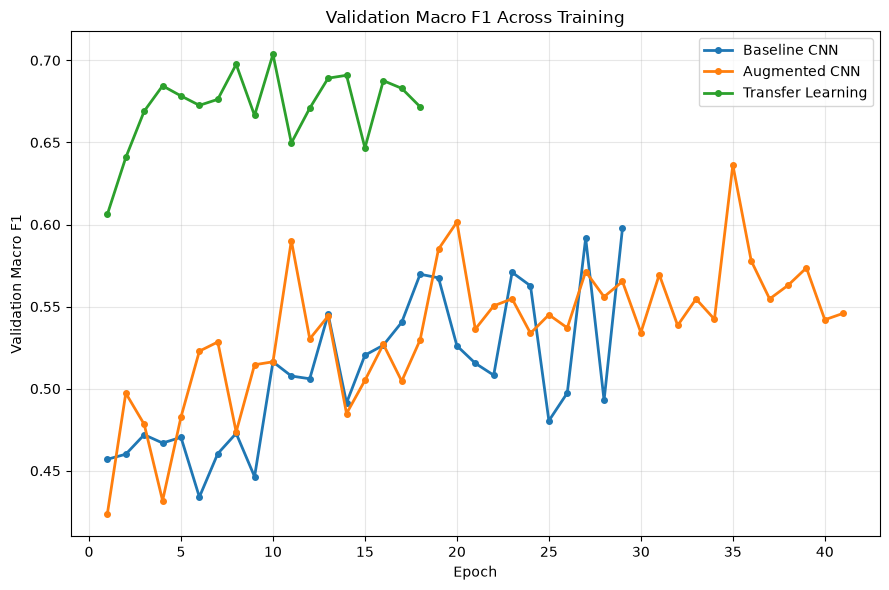

PosixPath('/home/uteam6/computer-vision-equine-grimace-scale/results/model_comparison/training_history_validation_macro_f1.png')

In [48]:
def plot_history_metric(
    histories: list[pd.DataFrame],
    metric: str,
    ylabel: str,
    title: str,
    output_filename: str,
) -> Path | None:
    available_histories = [
        history
        for history in histories
        if (
            metric in history.columns
            and history[metric].notna().any()
        )
    ]

    if not available_histories:
        print(
            f"Skipping {title}: no {metric} column found."
        )
        return None

    figure, axis = plt.subplots(
        figsize=(9, 6)
    )

    for history in available_histories:
        axis.plot(
            history["epoch"],
            history[metric],
            marker="o",
            linewidth=2,
            markersize=4,
            label=history["model"].iloc[0],
        )

    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.3)
    axis.legend()
    figure.tight_layout()

    output_path = (
        MODEL_COMPARISON_DIR
        / output_filename
    )
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)

    return output_path


plot_history_metric(
    histories=history_frames,
    metric="validation_loss",
    ylabel="Validation Loss",
    title="Validation Loss Across Training",
    output_filename=(
        "training_history_validation_loss.png"
    ),
)

plot_history_metric(
    histories=history_frames,
    metric="validation_accuracy",
    ylabel="Validation Accuracy",
    title="Validation Accuracy Across Training",
    output_filename=(
        "training_history_validation_accuracy.png"
    ),
)

plot_history_metric(
    histories=history_frames,
    metric="validation_macro_f1",
    ylabel="Validation Macro F1",
    title="Validation Macro F1 Across Training",
    output_filename=(
        "training_history_validation_macro_f1.png"
    ),
)


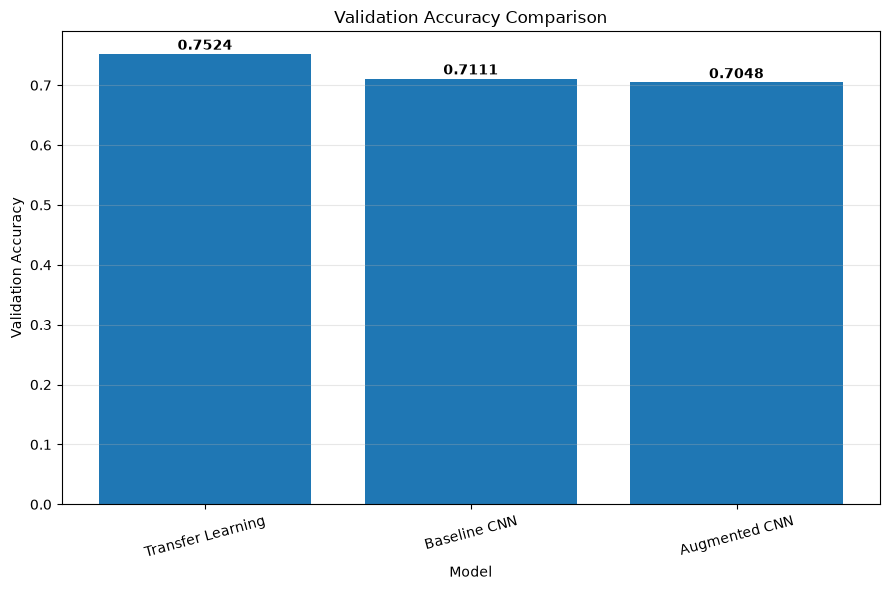

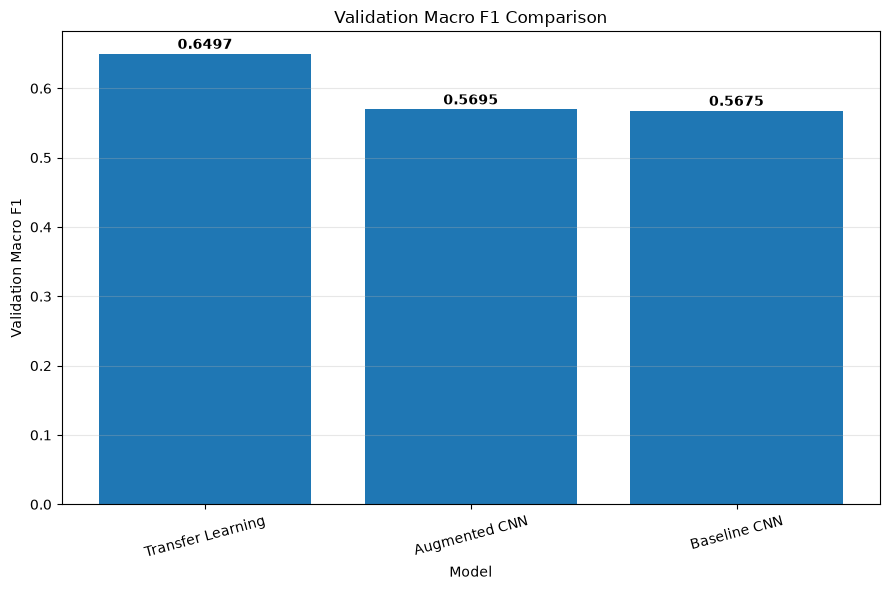

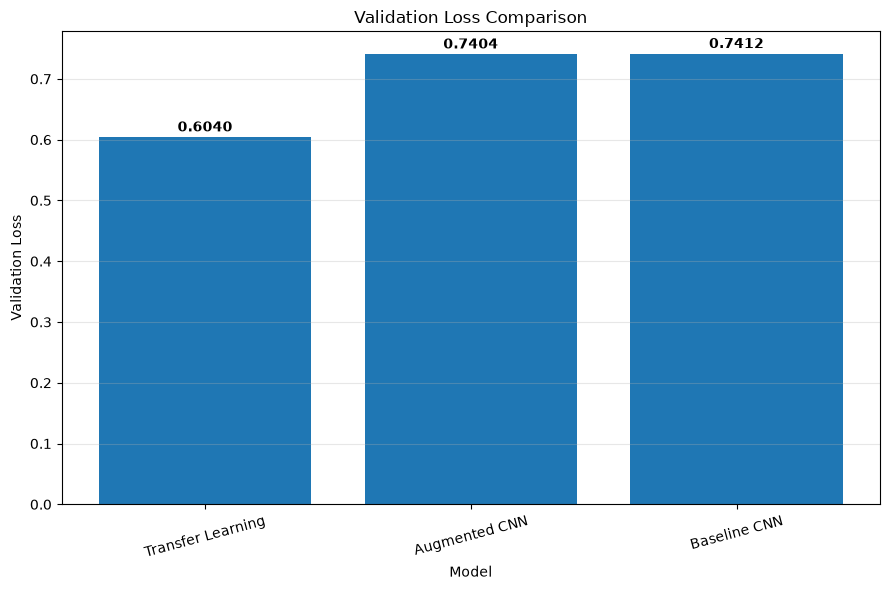

PosixPath('/home/uteam6/computer-vision-equine-grimace-scale/results/model_comparison/validation_loss_comparison.png')

In [49]:
def create_bar_comparison(
    dataframe: pd.DataFrame,
    metric: str,
    ylabel: str,
    title: str,
    output_filename: str,
    higher_is_better: bool,
) -> Path:
    ordered = dataframe.sort_values(
        metric,
        ascending=not higher_is_better,
    )

    figure, axis = plt.subplots(
        figsize=(9, 6)
    )

    bars = axis.bar(
        ordered["model"],
        ordered[metric],
    )

    axis.set_title(title)
    axis.set_xlabel("Model")
    axis.set_ylabel(ylabel)
    axis.tick_params(
        axis="x",
        rotation=15,
    )
    axis.grid(
        axis="y",
        alpha=0.3,
    )

    maximum = ordered[metric].max()
    minimum = ordered[metric].min()
    spread = max(
        maximum - minimum,
        abs(maximum) * 0.05,
        0.01,
    )

    for bar, value in zip(
        bars,
        ordered[metric],
    ):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + spread * 0.03,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    figure.tight_layout()

    output_path = (
        MODEL_COMPARISON_DIR
        / output_filename
    )
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(figure)

    return output_path


create_bar_comparison(
    evaluation_df,
    metric="validation_accuracy",
    ylabel="Validation Accuracy",
    title="Validation Accuracy Comparison",
    output_filename=(
        "validation_accuracy_comparison.png"
    ),
    higher_is_better=True,
)

create_bar_comparison(
    evaluation_df,
    metric="macro_f1",
    ylabel="Validation Macro F1",
    title="Validation Macro F1 Comparison",
    output_filename=(
        "validation_macro_f1_comparison.png"
    ),
    higher_is_better=True,
)

create_bar_comparison(
    evaluation_df,
    metric="validation_loss",
    ylabel="Validation Loss",
    title="Validation Loss Comparison",
    output_filename=(
        "validation_loss_comparison.png"
    ),
    higher_is_better=False,
)


In [50]:
rankings_df = (
    experiment_summary_df
    .sort_values(
        by=[
            "macro_f1",
            "validation_accuracy",
            "validation_loss",
            "trainable_parameter_count",
        ],
        ascending=[
            False,
            False,
            True,
            True,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

rankings_df.insert(
    0,
    "rank",
    np.arange(1, len(rankings_df) + 1),
)

display_columns = [
    "rank",
    "model",
    "macro_f1",
    "validation_accuracy",
    "validation_loss",
    "macro_precision",
    "macro_recall",
    "weighted_f1",
    "parameter_count",
    "trainable_parameter_count",
    "best_epoch",
    "training_time_seconds",
]

display(
    rankings_df[display_columns].style.format(
        {
            "macro_f1": "{:.4f}",
            "validation_accuracy": "{:.4f}",
            "validation_loss": "{:.4f}",
            "macro_precision": "{:.4f}",
            "macro_recall": "{:.4f}",
            "weighted_f1": "{:.4f}",
            "parameter_count": "{:,.0f}",
            "trainable_parameter_count": "{:,.0f}",
            "best_epoch": "{:.0f}",
            "training_time_seconds": "{:.2f}",
        },
        na_rep="Not recorded",
    )
)

winner_row = rankings_df.iloc[0]
WINNER_NAME = str(winner_row["model"])

winner_specification = next(
    specification
    for specification in MODEL_SPECIFICATIONS
    if specification.display_name == WINNER_NAME
)

print(f"Selected final model: {WINNER_NAME}")
print(
    "Validation Macro F1:",
    f"{winner_row['macro_f1']:.4f}",
)


,rank,model,macro_f1,validation_accuracy,validation_loss,macro_precision,macro_recall,weighted_f1,parameter_count,trainable_parameter_count,best_epoch,training_time_seconds
0,1,Transfer Learning,0.6497,0.7524,0.6040,0.6483,0.6615,0.7567,"11,178,051","11,178,051",10,Not recorded
1,2,Augmented CNN,0.5695,0.7048,0.7404,0.5928,0.6042,0.7120,"389,667","389,667",35,Not recorded
2,3,Baseline CNN,0.5675,0.7111,0.7412,0.5719,0.5828,0.7148,"389,667","389,667",29,Not recorded


Selected final model: Transfer Learning
Validation Macro F1: 0.6497


In [51]:
experiment_summary_path = (
    MODEL_COMPARISON_DIR
    / "experiment_summary.csv"
)
rankings_path = (
    MODEL_COMPARISON_DIR
    / "model_rankings.csv"
)
combined_history_path = (
    MODEL_COMPARISON_DIR
    / "combined_training_histories.csv"
)
winner_history_path = (
    MODEL_COMPARISON_DIR
    / "best_model_history.csv"
)
winner_predictions_path = (
    MODEL_COMPARISON_DIR
    / "best_model_validation_predictions.csv"
)

experiment_summary_df.to_csv(
    experiment_summary_path,
    index=False,
)
rankings_df.to_csv(
    rankings_path,
    index=False,
)
combined_history_df.to_csv(
    combined_history_path,
    index=False,
)

winner_history_df = next(
    history
    for history in history_frames
    if history["model"].iloc[0] == WINNER_NAME
)
winner_history_df.to_csv(
    winner_history_path,
    index=False,
)

winner_predictions = prediction_cache[
    WINNER_NAME
]

pd.DataFrame(
    {
        "target": winner_predictions["targets"],
        "prediction": (
            winner_predictions["predictions"]
        ),
        "target_name": [
            CLASS_NAMES[index]
            for index in winner_predictions[
                "targets"
            ]
        ],
        "prediction_name": [
            CLASS_NAMES[index]
            for index in winner_predictions[
                "predictions"
            ]
        ],
        "correct": (
            winner_predictions["targets"]
            == winner_predictions["predictions"]
        ),
    }
).to_csv(
    winner_predictions_path,
    index=False,
)

canonical_checkpoint_path = (
    FINAL_MODEL_DIR / "best_model.pth"
)
comparison_checkpoint_path = (
    MODEL_COMPARISON_DIR / "best_model.pth"
)

# Copy the original checkpoint byte-for-byte so no metadata
# or optimizer information from the winning phase is lost.
shutil.copy2(
    winner_specification.checkpoint_path,
    canonical_checkpoint_path,
)
shutil.copy2(
    winner_specification.checkpoint_path,
    comparison_checkpoint_path,
)

shutil.copy2(
    winner_specification.history_path,
    FINAL_MODEL_DIR / "best_model_history.csv",
)

print("Saved:", experiment_summary_path)
print("Saved:", rankings_path)
print("Saved:", canonical_checkpoint_path)


Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/model_comparison/experiment_summary.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/model_comparison/model_rankings.csv
Saved: /home/uteam6/computer-vision-equine-grimace-scale/results/final_model/best_model.pth


In [52]:
def json_safe(value: Any) -> Any:
    if pd.isna(value):
        return None

    if isinstance(
        value,
        (
            np.integer,
            np.floating,
        ),
    ):
        return value.item()

    if isinstance(value, Path):
        return str(value)

    return value


selection_record = {
    "selected_model": WINNER_NAME,
    "model_family": winner_specification.family,
    "selection_metric": "validation_macro_f1",
    "selection_rule": [
        "highest validation Macro F1",
        "highest validation accuracy",
        "lowest validation loss",
        "fewest trainable parameters",
    ],
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "normalization_mean": (
        NORMALIZATION_MEAN
    ),
    "normalization_std": NORMALIZATION_STD,
    "validation_csv": str(VALIDATION_CSV),
    "source_checkpoint": str(
        winner_specification.checkpoint_path
    ),
    "canonical_checkpoint": str(
        canonical_checkpoint_path
    ),
    "source_history": str(
        winner_specification.history_path
    ),
    "metrics": {
        key: json_safe(winner_row[key])
        for key in [
            "validation_loss",
            "validation_accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
            "parameter_count",
            "trainable_parameter_count",
            "best_epoch",
            "training_time_seconds",
        ]
    },
    "test_set_used": False,
}

final_model_json_path = (
    MODEL_COMPARISON_DIR
    / "final_model.json"
)
canonical_json_path = (
    FINAL_MODEL_DIR
    / "final_model.json"
)

for path in [
    final_model_json_path,
    canonical_json_path,
]:
    with path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            selection_record,
            file,
            indent=2,
        )

print(
    json.dumps(
        selection_record,
        indent=2,
    )
)


{
  "selected_model": "Transfer Learning",
  "model_family": "resnet18",
  "selection_metric": "validation_macro_f1",
  "selection_rule": [
    "highest validation Macro F1",
    "highest validation accuracy",
    "lowest validation loss",
    "fewest trainable parameters"
  ],
  "class_names": [
    "No Pain",
    "Moderate Pain",
    "Severe Pain"
  ],
  "num_classes": 3,
  "image_size": 224,
  "normalization_mean": [
    0.485,
    0.456,
    0.406
  ],
  "normalization_std": [
    0.229,
    0.224,
    0.225
  ],
  "validation_csv": "/home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv",
  "source_checkpoint": "/home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/best_transfer_model.pth",
  "canonical_checkpoint": "/home/uteam6/computer-vision-equine-grimace-scale/results/final_model/best_model.pth",
  "source_history": "/home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/best_transfer_history.csv",
  "metrics":

In [53]:
runner_up_name = (
    str(rankings_df.iloc[1]["model"])
    if len(rankings_df) > 1
    else None
)

conclusion = (
    f"Among the three evaluated candidates, "
    f"**{WINNER_NAME}** achieved the highest validation "
    f"Macro F1 score of **{winner_row['macro_f1']:.4f}**. "
    f"It obtained a validation accuracy of "
    f"**{winner_row['validation_accuracy']:.4f}** and a "
    f"validation loss of "
    f"**{winner_row['validation_loss']:.4f}**. "
)

if runner_up_name is not None:
    runner_up_row = rankings_df.iloc[1]
    macro_f1_difference = (
        winner_row["macro_f1"]
        - runner_up_row["macro_f1"]
    )

    conclusion += (
        f"Its Macro F1 exceeded the second-ranked "
        f"model, **{runner_up_name}**, by "
        f"**{macro_f1_difference:.4f}**. "
    )

conclusion += (
    "Because Macro F1 gives equal importance to all pain "
    "classes, it was used as the primary model-selection "
    "criterion. The selected checkpoint has been copied to "
    "`results/final_model/best_model.pth` for use in "
    "Phases 7–9. The test set was not accessed during "
    "model selection."
)

display(
    Markdown(
        "### Phase 6 conclusion\n\n"
        + conclusion
    )
)

conclusion_path = (
    MODEL_COMPARISON_DIR
    / "phase_6_conclusion.txt"
)

conclusion_path.write_text(
    conclusion,
    encoding="utf-8",
)


### Phase 6 conclusion

Among the three evaluated candidates, **Transfer Learning** achieved the highest validation Macro F1 score of **0.6497**. It obtained a validation accuracy of **0.7524** and a validation loss of **0.6040**. Its Macro F1 exceeded the second-ranked model, **Augmented CNN**, by **0.0801**. Because Macro F1 gives equal importance to all pain classes, it was used as the primary model-selection criterion. The selected checkpoint has been copied to `results/final_model/best_model.pth` for use in Phases 7–9. The test set was not accessed during model selection.

559

In [54]:
expected_outputs = [
    MODEL_COMPARISON_DIR
    / "experiment_summary.csv",
    MODEL_COMPARISON_DIR
    / "validation_accuracy_comparison.png",
    MODEL_COMPARISON_DIR
    / "validation_macro_f1_comparison.png",
    MODEL_COMPARISON_DIR
    / "validation_loss_comparison.png",
    MODEL_COMPARISON_DIR
    / "model_rankings.csv",
    MODEL_COMPARISON_DIR
    / "final_model.json",
    MODEL_COMPARISON_DIR
    / "best_model.pth",
    MODEL_COMPARISON_DIR
    / "best_model_history.csv",
    MODEL_COMPARISON_DIR
    / "best_model_validation_predictions.csv",
    MODEL_COMPARISON_DIR
    / "phase_6_conclusion.txt",
    FINAL_MODEL_DIR
    / "best_model.pth",
    FINAL_MODEL_DIR
    / "final_model.json",
]

verification_df = pd.DataFrame(
    [
        {
            "output": str(
                path.relative_to(PROJECT_ROOT)
            ),
            "exists": path.exists(),
            "size_bytes": (
                path.stat().st_size
                if path.exists()
                else 0
            ),
        }
        for path in expected_outputs
    ]
)

display(verification_df)

missing_outputs = verification_df.loc[
    ~verification_df["exists"],
    "output",
].tolist()

if missing_outputs:
    raise RuntimeError(
        "The following expected outputs are missing:\n"
        + "\n".join(missing_outputs)
    )

print(
    "Phase 6 completed successfully. "
    "No test data was used."
)


,output,exists,size_bytes
0,results/model_comparison/experiment_summary.csv,True,1473
1,results/model_comparison/validation_accuracy_c...,True,112058
2,results/model_comparison/validation_macro_f1_c...,True,112591
3,results/model_comparison/validation_loss_compa...,True,107299
4,results/model_comparison/model_rankings.csv,True,1484
5,results/model_comparison/final_model.json,True,1414
6,results/model_comparison/best_model.pth,True,134271850
7,results/model_comparison/best_model_history.csv,True,1813
8,results/model_comparison/best_model_validation...,True,9175
9,results/model_comparison/phase_6_conclusion.txt,True,561


Phase 6 completed successfully. No test data was used.
